## Title

### 📊 Netflix Content Strategy Analysis Using Python

### Business Problem Statement

Netflix wants to understand content trends, audience preferences, and platform growth patterns to improve content acquisition and engagement strategy.

### Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

### Load Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('netflix_titles.csv')
df.head()

Saving netflix_titles.csv to netflix_titles.csv


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Dataset Overview

### Shape and Duplicate Check

In [4]:
print("Shape:", df.shape)

print("Duplicate Rows:", df.duplicated().sum())

Shape: (8807, 12)
Duplicate Rows: 0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## Data Cleaning

### Detect Hidden Missing Values

In [7]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

### Create Year Added Column

In [8]:
df['year_added'] = df['date_added'].dt.year

### Fill Missing Values

In [9]:
df['country'].fillna('Unknown', inplace=True)
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)

/tmp/ipykernel_26134/1810794559.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)
/tmp/ipykernel_26134/1810794559.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

## Exploratory Data Analysis

### Business Questions and Analysis

### Question 1:
What type of content dominates Netflix?

### Business Objective:

Understand whether Netflix focuses more on Movies or TV Shows.

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


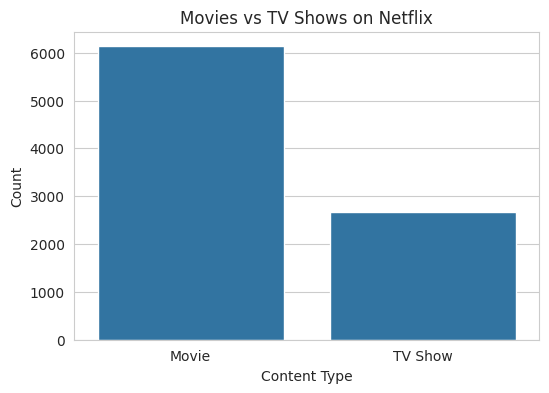

In [26]:
content_type = df['type'].value_counts()

# Table
print(content_type)

# Graph
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

### Business Insight

Movies dominate Netflix’s content library, indicating a stronger focus on short-duration entertainment content.

### Business Recommendation

Netflix can continue expanding movie content while increasing investment in binge-worthy TV Shows to improve user retention.

### Question 2:
Which countries produce the most Netflix content?

### Business Objective:

Identify key content-producing markets.

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


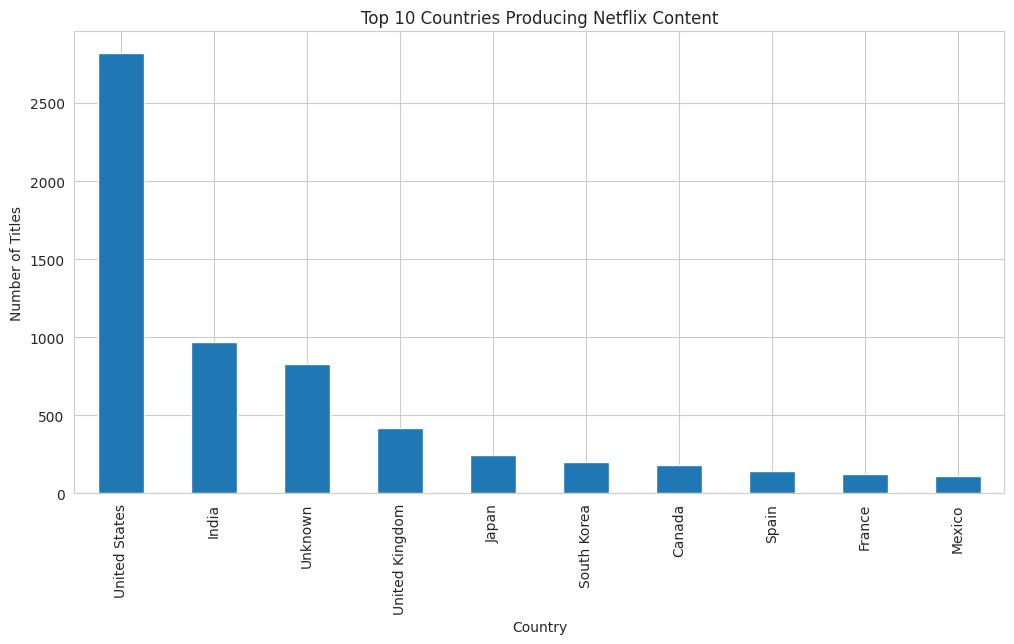

In [27]:
top_countries = df['country'].value_counts().head(10)

# Show Table
print(top_countries)

# Then Visualization
plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

### Business Insight

The United States contributes the largest share of Netflix content, followed by India and the United Kingdom.

### Business Recommendation

Netflix should diversify content sourcing by increasing investments in emerging entertainment markets.

### Question 3:
Which genres are most popular?

### Business Objective:

Understand dominant audience preferences.

 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64


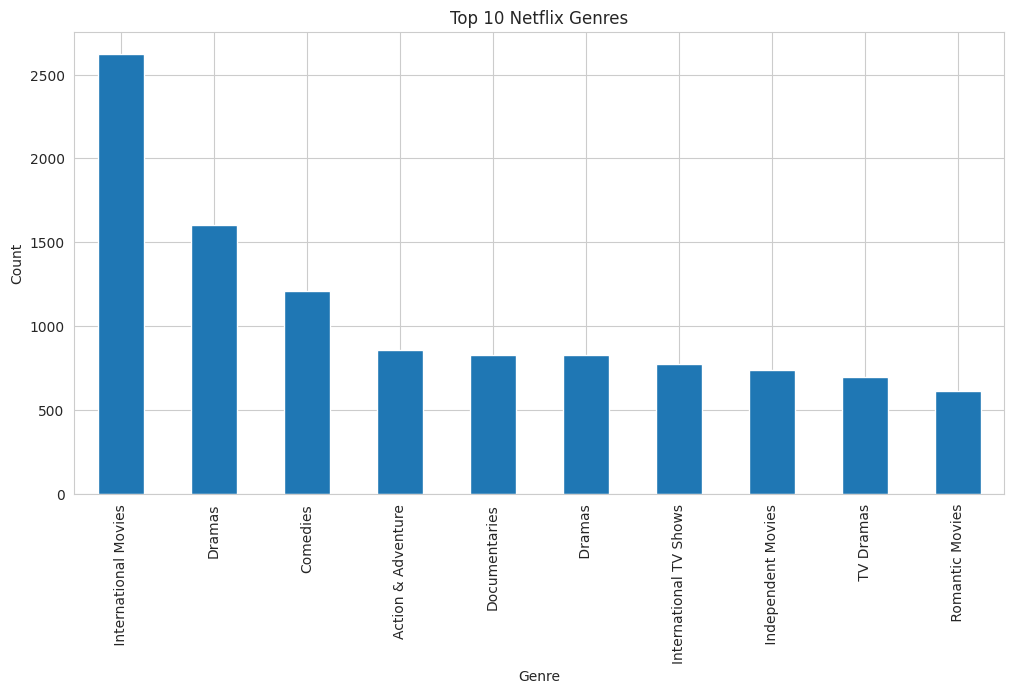

In [28]:
genres = df['listed_in'].str.split(',', expand=True).stack()

top_genres = genres.value_counts().head(10)

# Table
print(top_genres)

# Graph
plt.figure(figsize=(12,6))

top_genres.plot(kind='bar')

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

### Business Insight

Drama and International Movies dominate the platform, showing strong audience demand for emotional and globally diverse storytelling.

### Business Recommendation

Netflix should continue investing in globally appealing drama-based content to maximize audience engagement.

#### Question 4:
How has Netflix content grown over time?

### Business Objective:

Analyze platform expansion trends.

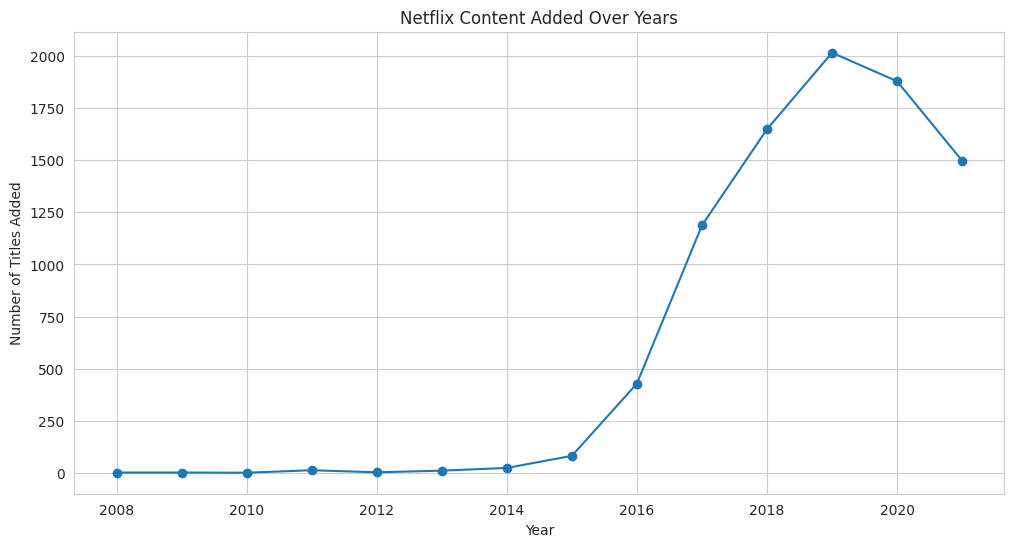

In [29]:
content_growth = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))

content_growth.plot(kind='line', marker='o')

plt.title("Netflix Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.show()

### Business Insight

Netflix experienced rapid content expansion after 2015, reflecting aggressive growth and increased investment in digital streaming content.

### Question 5:
Which audience ratings are most common?

### Business Objective:

Understand target audience categories.

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


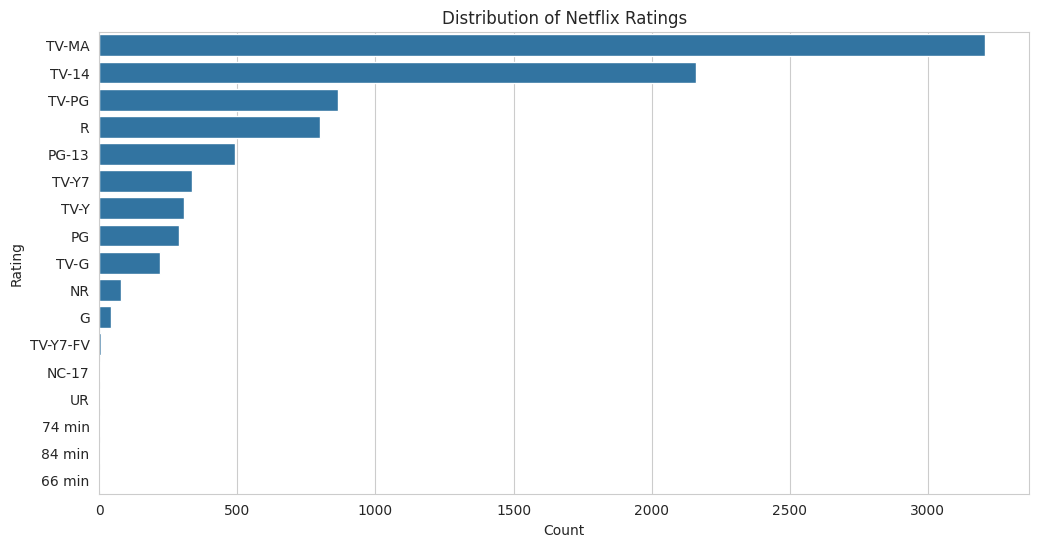

In [30]:
ratings = df['rating'].value_counts()

# Table
print(ratings)

# Graph
plt.figure(figsize=(12,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Distribution of Netflix Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")

plt.show()

### Business Insight

TV-MA and TV-14 dominate the platform, indicating Netflix strongly targets mature and teenage audiences.

### Business Recommendation

Netflix can improve family-oriented offerings to broaden audience reach.

### Question 6:
Which month sees the highest content additions?

### Business Objective:

Understand seasonal content release patterns.

month_added
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
Name: count, dtype: int64


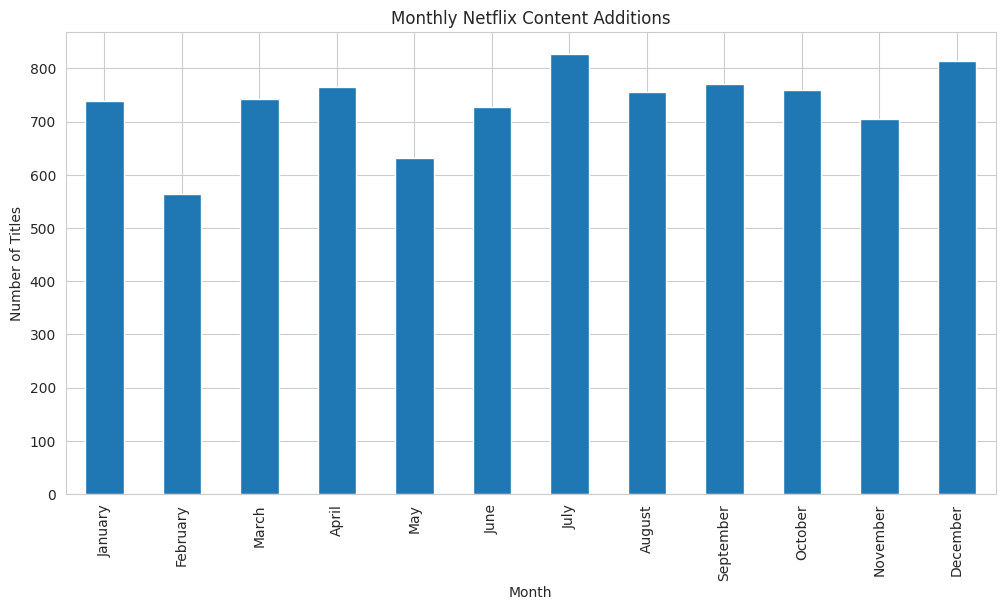

In [31]:
df['month_added'] = df['date_added'].dt.month_name()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_additions = (
    df['month_added']
    .value_counts()
    .reindex(month_order)
)

# Table
print(monthly_additions)

# Graph
plt.figure(figsize=(12,6))

monthly_additions.plot(kind='bar')

plt.title("Monthly Netflix Content Additions")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.show()

### Business Insight

Netflix adds large amounts of content during specific months, reflecting seasonal audience engagement strategies.

### Business Recommendation

Netflix should align major content releases with holiday seasons and peak user activity periods.

### Question 7:
What is the average duration of Netflix movies?

### Business Objective:

Understand user content consumption patterns.

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64


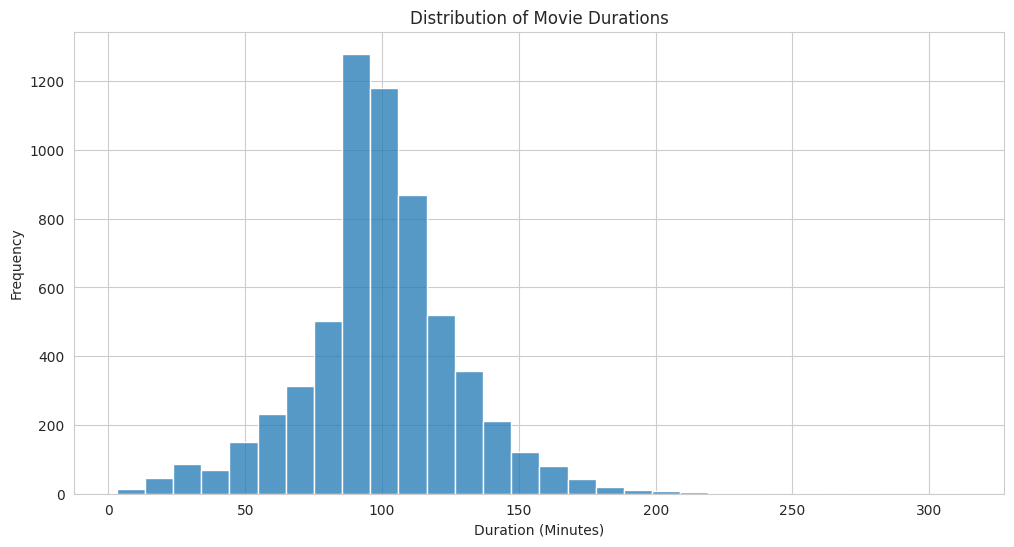

In [32]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = (
    movies['duration']
    .str.replace(' min', '')
    .astype(float)
)

# Table
print(movies['duration'].describe())

# Graph
plt.figure(figsize=(12,6))

sns.histplot(movies['duration'], bins=30)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")

plt.show()

### Business Insight

Most Netflix movies fall between 80–120 minutes, reflecting standard audience viewing preferences.

### Business Recommendation

Netflix should continue optimizing movie durations for audience engagement and completion rates.

### Question 8:
Are Movies or TV Shows growing faster?

## Business Objective:

Analyze changing content strategy over time.

type         Movie  TV Show
year_added                 
2008.0         1.0      1.0
2009.0         2.0      NaN
2010.0         1.0      NaN
2011.0        13.0      NaN
2012.0         3.0      NaN
2013.0         6.0      5.0
2014.0        19.0      5.0
2015.0        56.0     26.0
2016.0       253.0    176.0
2017.0       839.0    349.0
2018.0      1237.0    412.0
2019.0      1424.0    592.0
2020.0      1284.0    595.0
2021.0       993.0    505.0


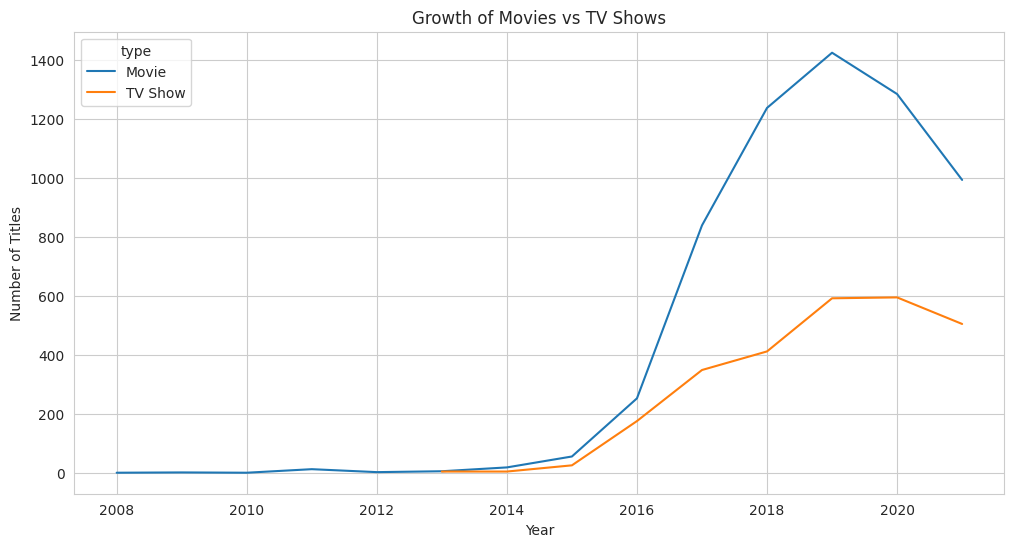

In [33]:
type_growth = (
    df.groupby(['year_added', 'type'])
    .size()
    .unstack()
)

# Table
print(type_growth)

# Graph
type_growth.plot(figsize=(12,6))

plt.title("Growth of Movies vs TV Shows")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

### Business Insight

TV Shows have grown rapidly in recent years due to rising demand for serialized and binge-watchable content.

### Business Recommendation

Netflix should continue increasing high-quality TV series investments to improve long-term subscriber retention.

### Question 9:
Which directors appear most frequently?

### Business Objective

Identify recurring creative partnerships.

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


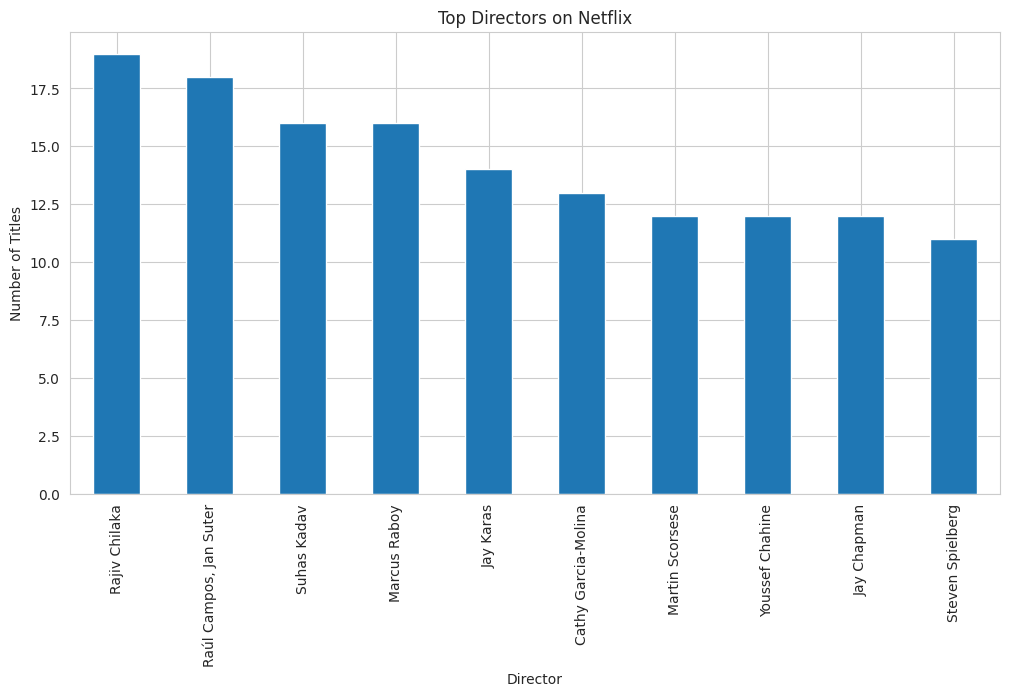

In [34]:
top_directors = (
    df[df['director'] != 'Unknown']['director']
    .value_counts()
    .head(10)
)

print(top_directors)

plt.figure(figsize=(12,6))

top_directors.plot(kind='bar')

plt.title("Top Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")

plt.show()

### Business Insight

Certain directors repeatedly collaborate with Netflix, indicating long-term content partnerships.

### Business Recommendation

Netflix should strengthen partnerships with high-performing directors to maintain content consistency and audience trust.

### Question 10:
Which release years contain the highest number of titles?

### Business Objective:

Identify dominant production periods.

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


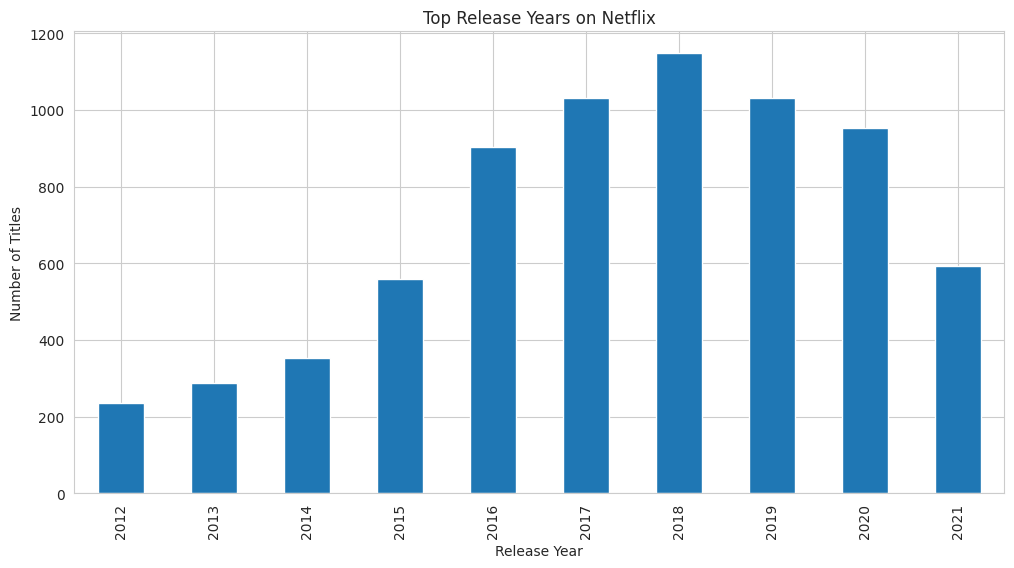

In [36]:
release_years = df['release_year'].value_counts().head(10)
release_years = (
    df['release_year']
    .value_counts()
    .sort_index()
    .tail(10)
)

# Table
print(release_years)

# Graph
plt.figure(figsize=(12,6))

release_years.sort_index().plot(kind='bar')

plt.title("Top Release Years on Netflix")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

### Business Insight

Recent years dominate Netflix’s catalog, showing a strong focus on modern and fresh content.


### Business Recommendation

Netflix should maintain a balance between new releases and classic content to appeal to broader audiences.

## ✅ Conclusion

The analysis of Netflix’s content library revealed several important business insights regarding content strategy, audience targeting, and platform growth.

Key findings from the analysis include:

Movies dominate the Netflix platform
TV Shows have grown rapidly in recent years
The United States produces the highest amount of content
Drama and International genres are highly popular
Mature audience content (TV-MA, TV-14) dominates the catalog
Significant content expansion occurred after 2015

The analysis also showed that Netflix strategically increases content additions during specific periods to maximize audience engagement and platform activity.

These findings can help Netflix improve its content acquisition strategy, audience targeting, and regional expansion planning.

##📌 Final Business Summary

This analysis revealed that Netflix’s growth and audience engagement are primarily influenced by:

Strong movie-focused content strategy
Rapid growth in binge-watchable TV Shows
High contribution from the United States and international markets
Popularity of Drama and International content
Dominance of mature audience categories
Aggressive content expansion after 2015

Netflix can further strengthen its platform by:

Expanding investments in international content
Increasing production of high-retention TV series
Balancing mature and family-friendly content
Optimizing seasonal release strategies
Building stronger partnerships with successful directors and creators

Overall, this project demonstrates how Exploratory Data Analysis (EDA) can be used to solve real-world business problems by identifying audience trends, content patterns, and strategic growth opportunities within the streaming industry.

### Author - Snehashish Pradhan